# Business Problem
### Problem Statement:

Predict the type of customer (Channel) based on their annual spending across product categories.

### Business Context:

A wholesale distributor wants to automatically classify whether a new customer belongs to:

* HORECA (Hotel/Restaurant/Cafe)

* Retail

based on their purchasing behavior.

Why this matters:

* Sales strategy differs for Retail vs HORECA

* Different discount structures

* Different marketing campaigns

* Different supply chain planning

* Better demand forecasting

### Objective:

Build a classification model that predicts Channel using spending features.

A wholesale distributor wants to classify customers into Retail or HORECA segments based on their annual spending across various product categories. This will help the company optimize sales strategies, improve inventory planning, and design targeted marketing campaigns.

### About the Dataset

1)	FRESH: annual spending (m.u.) on fresh products (Continuous);
2)	MILK: annual spending (m.u.) on milk products (Continuous);
3)	GROCERY: annual spending (m.u.)on grocery products (Continuous);
4)	FROZEN: annual spending (m.u.)on frozen products (Continuous)
5)	DETERGENTS_PAPER: annual spending (m.u.) on detergents and paper products (Continuous)
6)	DELICATESSEN: annual spending (m.u.)on and delicatessen products (Continuous);
7)	CHANNEL: customersâ€™ Channel - Horeca (Hotel/Restaurant/CafÃ©) or Retail channel (Nominal)
8)	REGION: customersâ€™ Region â€“ Lisnon, Oporto or Other (Nominal)

### Basic Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df= pd.read_csv('Wholesale customers data.csv')

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Basic Checks / Non visual Analysis

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop('Region',axis=1,inplace=True)

Visual Analysis

Univariate Analysis

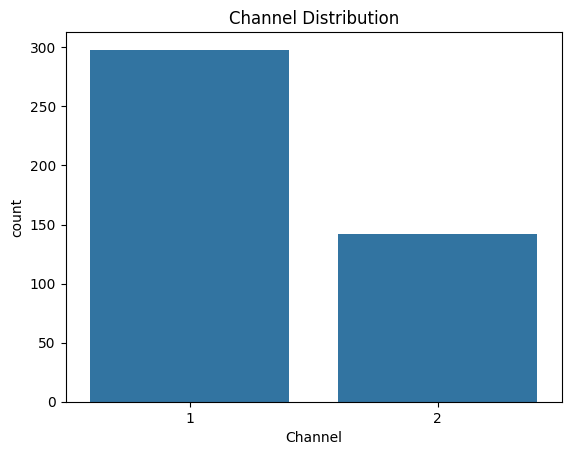

In [9]:
sns.countplot(x="Channel", data=df)
plt.title("Channel Distribution")
plt.show()

In [10]:
# Check imbalance
df["Channel"].value_counts(normalize=True)

Channel
1    0.677273
2    0.322727
Name: proportion, dtype: float64

Distribution + Skewness

note:- column 1 is for the target value so i am starting from the 2

In [11]:
for col in df.columns[2:]:
    print(col, "Skewness:", df[col].skew())

Milk Skewness: 4.053754849210881
Grocery Skewness: 3.5874286903915453
Frozen Skewness: 5.9079856924559575
Detergents_Paper Skewness: 3.6318506306913645
Delicassen Skewness: 11.151586478906117


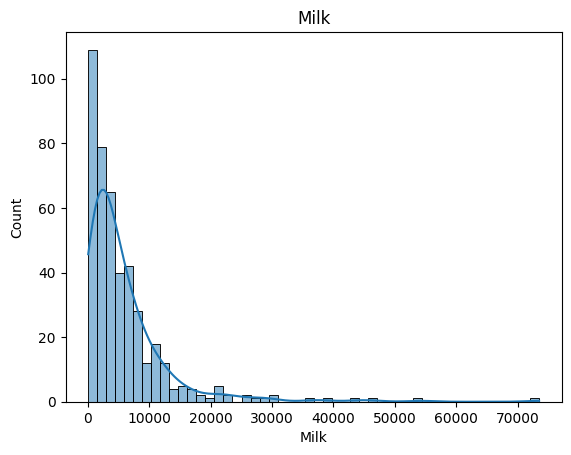

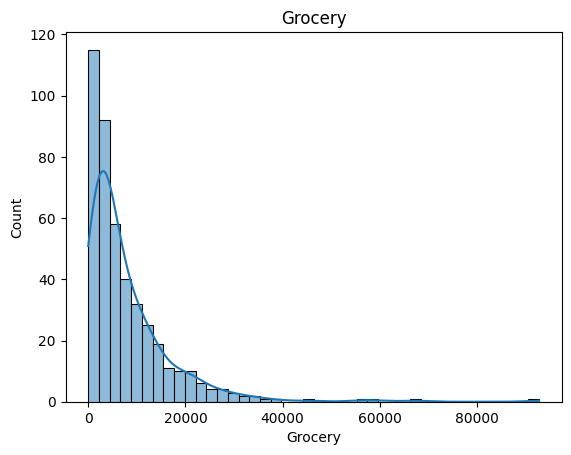

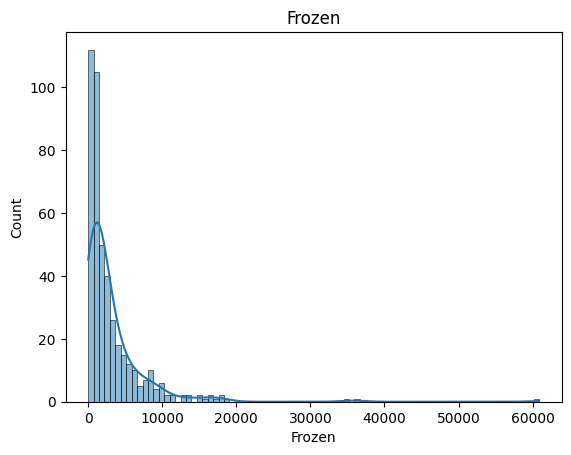

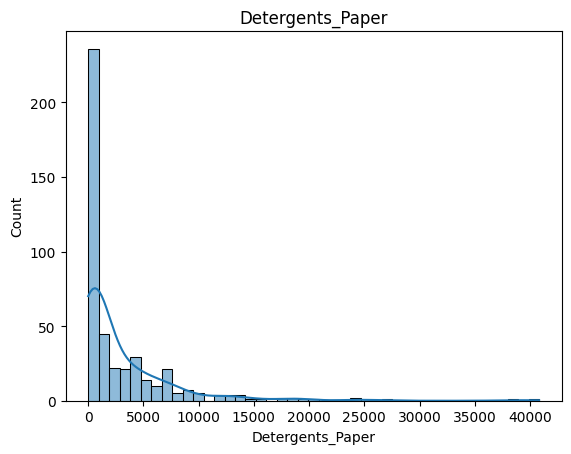

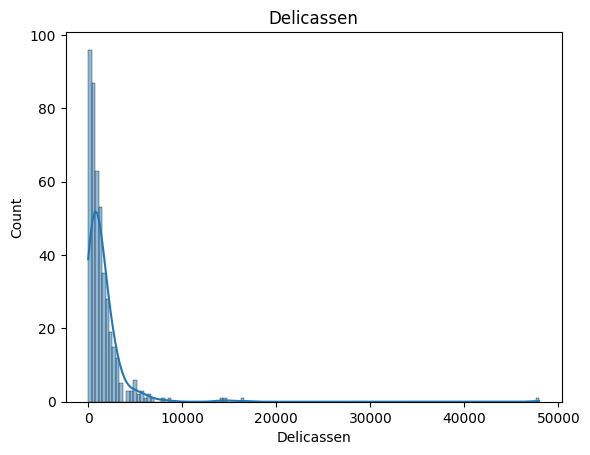

In [12]:
# Histograms
for col in df.columns[2:]:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Observation:
* Heavy right skew
* Non-normal distribution
* Large outliers

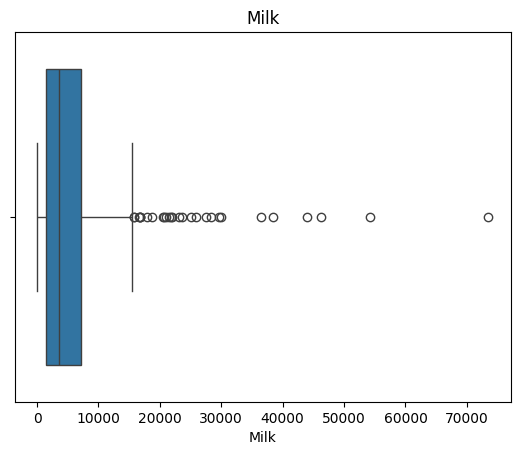

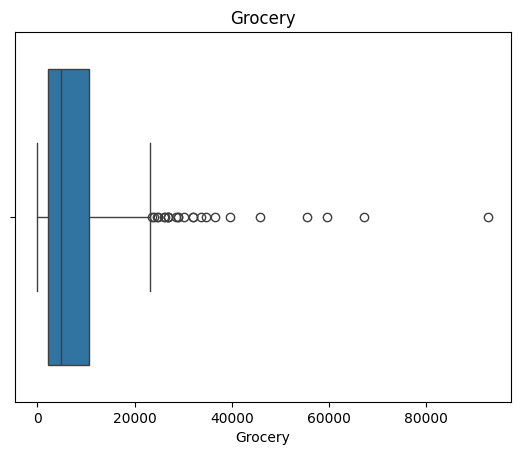

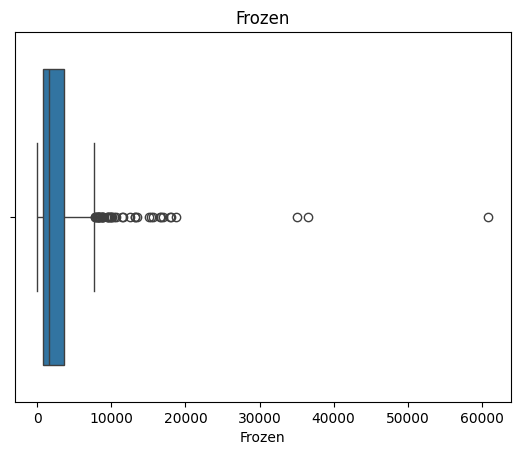

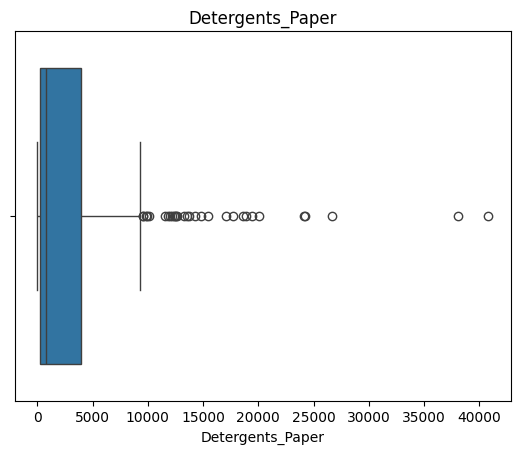

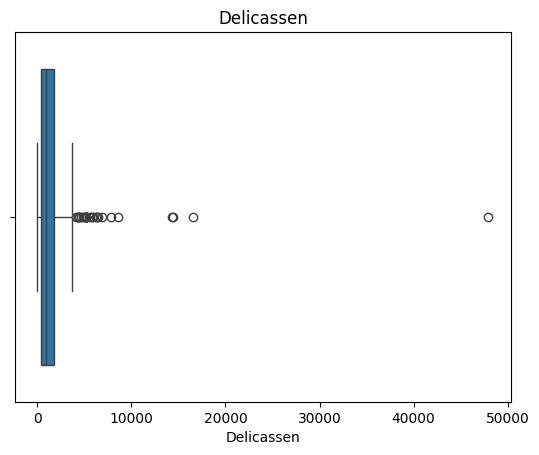

In [13]:
# Boxplot (Outlier Detection)
for col in df.columns[2:]:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Bivariate Analysis

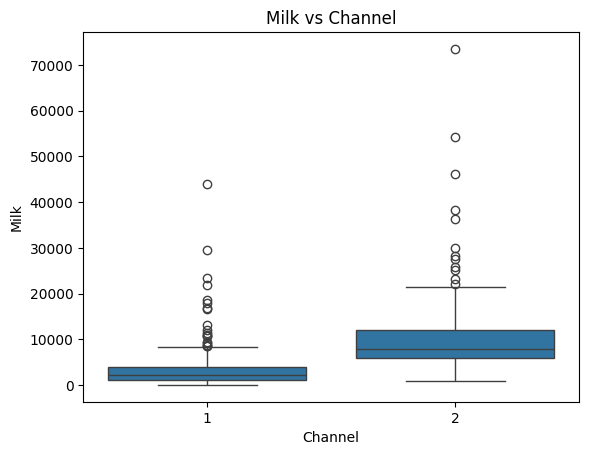

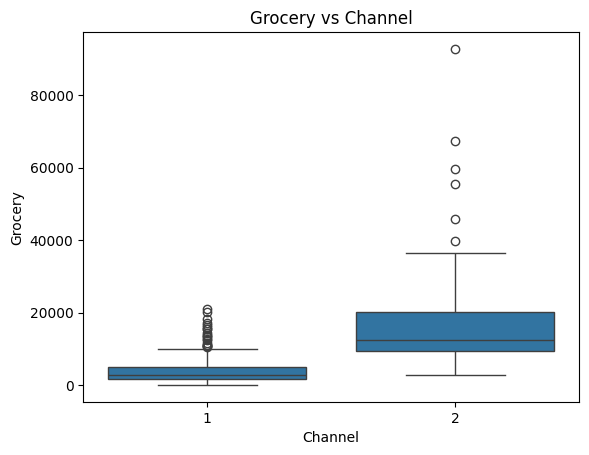

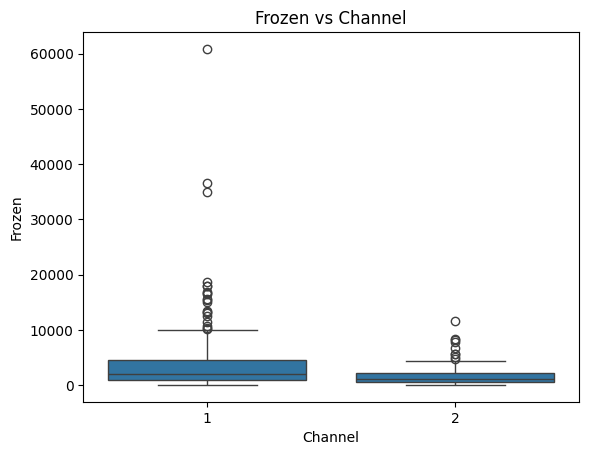

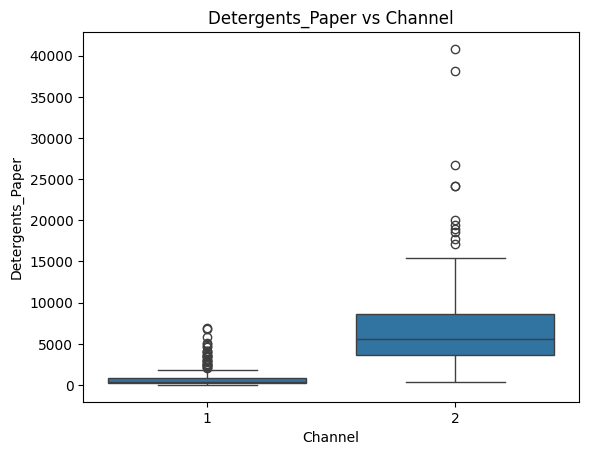

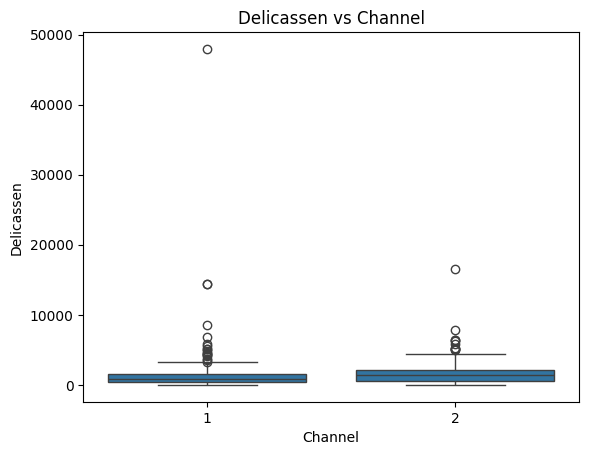

In [14]:
# Feature vs Target
for col in df.columns[2:]:
    sns.boxplot(x="Channel", y=col, data=df)
    plt.title(f"{col} vs Channel")
    plt.show()

Insights you will likely see:

* Retail → Higher Grocery & Detergents

* HORECA → Higher Fresh

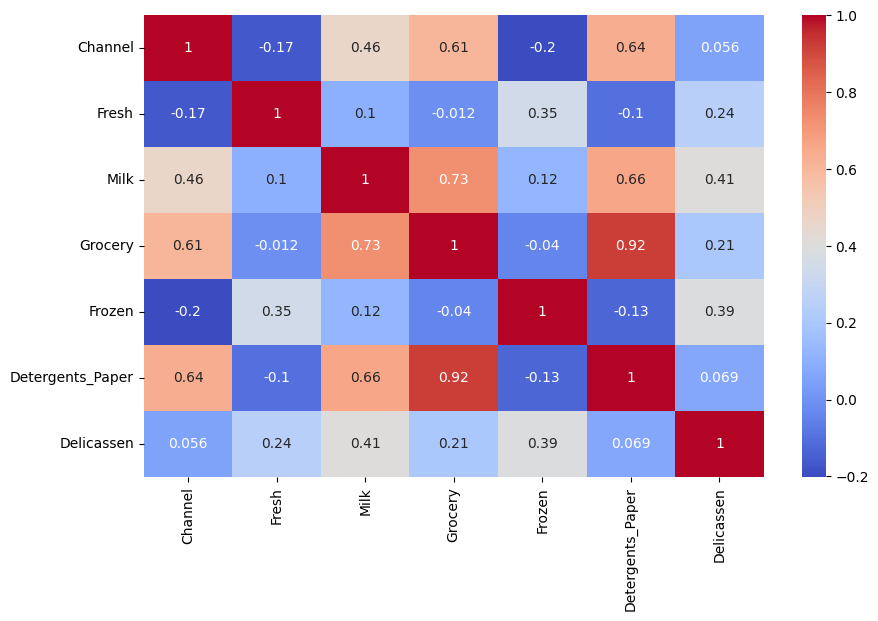

In [15]:
# Correlation Matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

Look for:

* |r| ≥ 0.8 → strong correlation

* 'Grocery' & 'Detergents_Paper' usually highly correlated

In [16]:
df.columns

Index(['Channel', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper',
       'Delicassen'],
      dtype='object')

In [17]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = df.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [18]:
## threshold--Domain expertise
corr_features=correlation(df,0.85)

In [19]:
corr_features

{'Detergents_Paper'}

In [20]:
df.drop(corr_features,axis=1,inplace=True)
df.columns

Index(['Channel', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Delicassen'], dtype='object')

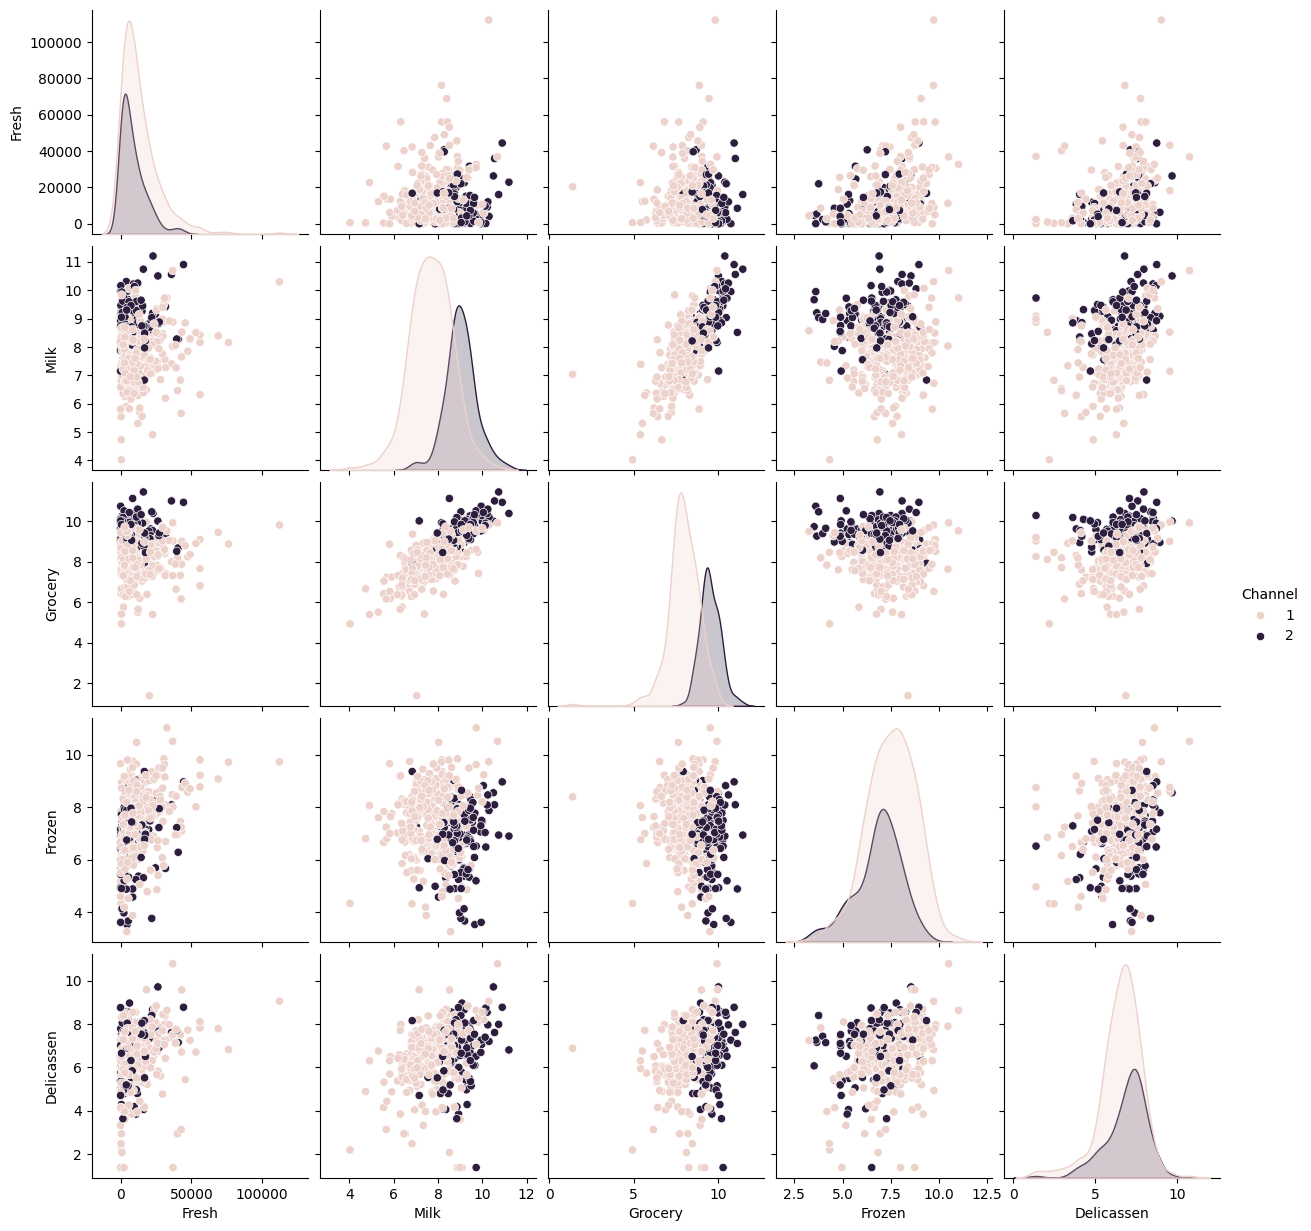

In [21]:
df_log = df.copy()
df_log[df.columns[2:]] = np.log1p(df[df.columns[2:]])

sns.pairplot(df_log, hue="Channel")
plt.show()

In [22]:
df[df.columns[2:]] = np.log1p(df[df.columns[2:]])

IQR Method (Controlled Removal)

If more than 10–15% removed → reconsider.

In [23]:
!pip install feature_engine


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
from feature_engine.outliers import Winsorizer

In [25]:


winsor = Winsorizer(
    capping_method="iqr",
    tail="both",
    fold=1.5,
    variables=list(df.columns[2:])   # <-- FIX
)

df_clean = winsor.fit_transform(df)

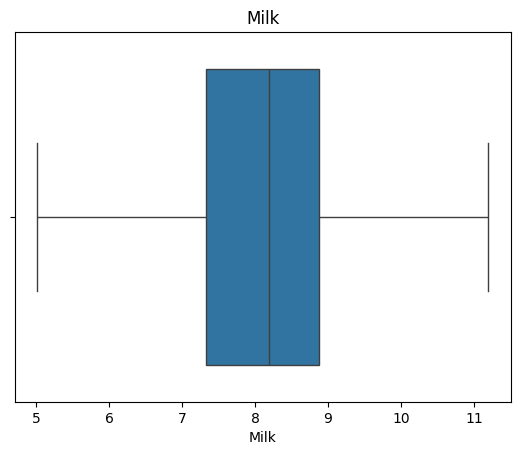

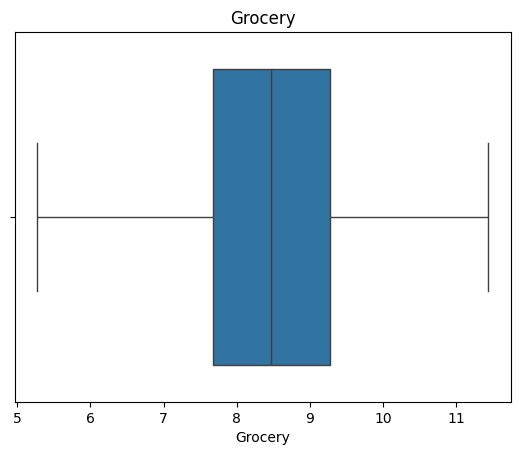

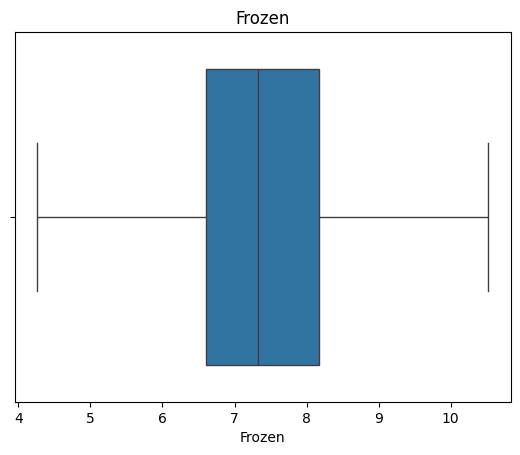

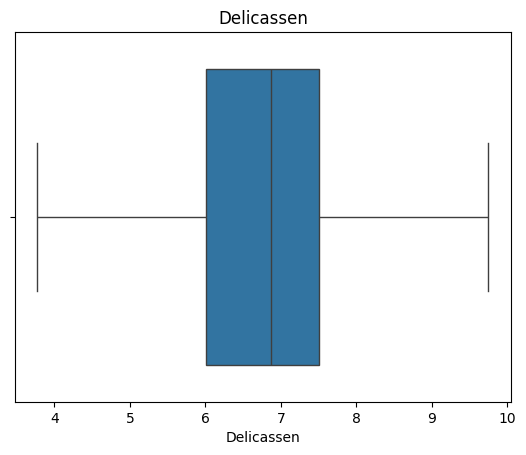

In [26]:
for col in df.columns[2:]:
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()


In [27]:
X=df_clean.drop('Channel',axis=1)
y=df_clean['Channel']

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

### Model Training


Logistic Regression

In [30]:
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [32]:
lr.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
y_pred_tr_test=lr.predict(X_test_scaled)

In [34]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
acc_test=accuracy_score(y_test,y_pred_tr_test)
acc_test

0.875

In [35]:
y_pred_lr_train=lr.predict(X_train_scaled)
acc_train=acc_test=accuracy_score(y_train,y_pred_lr_train)
acc_train

0.8863636363636364

Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [37]:
y_pred_dt_test = dt.predict(X_test)

In [38]:
acc_test_dt = accuracy_score(y_test, y_pred_dt_test)
acc_test_dt

0.8522727272727273

In [39]:
y_pred_dt_train = dt.predict(X_train)
acc_train_dt = accuracy_score(y_train, y_pred_dt_train)
acc_train_dt

0.9431818181818182

Navie Bayes

In [40]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [41]:
y_pred_nb_test=nb.predict(X_test)
acc_test_nb=accuracy_score(y_test,y_pred_nb_test)
acc_test_nb


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


0.7386363636363636

In [42]:
y_pred_nb_train=nb.predict(X_train)
acc_train_nb=accuracy_score(y_train,y_pred_nb_train)
acc_train_nb

C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


0.6619318181818182

KNN

In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [44]:
y_pred_knn_test=knn.predict(X_test)
acc_test_knn=accuracy_score(y_test,y_pred_knn_test)
acc_test_knn

C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


0.7272727272727273

In [45]:
y_pred_knn_train=knn.predict(X_train)
acc_train_knn=accuracy_score(y_train,y_pred_knn_train)
acc_train_knn

C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


0.65625

In [46]:
print("LR Accuracy:", accuracy_score(y_test, y_pred_tr_test))
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt_test))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn_test))
print("NB Accuracy:", accuracy_score(y_test, y_pred_nb_test))

LR Accuracy: 0.875
DT Accuracy: 0.8522727272727273
KNN Accuracy: 0.7272727272727273
NB Accuracy: 0.7386363636363636


In [47]:
from sklearn.metrics import f1_score

models_results = {
    "LR": y_pred_tr_test,
    "DT": y_pred_dt_test,
    "KNN": y_pred_knn_test,
    "NB": y_pred_nb_test
}

for name, pred in models_results.items():
    print(name, "F1-score:", f1_score(y_test, pred))

LR F1-score: 0.912
DT F1-score: 0.8888888888888888
KNN F1-score: 0.8421052631578947
NB F1-score: 0.8496732026143791


Hyperparameter Tuning

In [48]:
from sklearn.model_selection import GridSearchCV

In [49]:
from sklearn.linear_model import LogisticRegression

params_grid_lr={
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best Params:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.9121751857517759


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [50]:
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

In [51]:
f1_score(y_test, y_pred_lr)

0.912

In [52]:
f1_score(y_train, best_lr.predict(X_train_scaled))

0.9141630901287554

Decision Tree Tuning

In [53]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Params:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV Score: 0.893179804569801


In [54]:
best_dt=grid_dt.best_estimator_
y_pred_dt=best_dt.predict(X_test_scaled)

C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [55]:
f1_score(y_test,y_pred_dt)


0.8496732026143791

In [56]:
f1_score(y_train,best_dt.predict(X_train))

0.9501084598698482

KNN Tuning

In [57]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best Params:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

Best Params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best CV Score: 0.9211962565109362


In [58]:
best_knn=grid_knn.best_estimator_
y_pred_knn=best_knn.predict(X_test_scaled)

In [59]:
f1_score(y_test,y_pred_knn)

0.9193548387096774

In [60]:
f1_score(y_train,best_knn.predict(X_train_scaled))

0.9237472766884531

Naive Bayes Tuning (GaussianNB)

In [61]:
from sklearn.naive_bayes import GaussianNB

param_grid_nb = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_nb.fit(X_train_scaled, y_train)

print("Best Params:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

Best Params: {'var_smoothing': 1e-09}
Best CV Score: 0.9134025110277056


In [62]:
y_pred_nb=grid_nb.predict(X_test_scaled)

In [63]:
f1_score(y_test,y_pred_nb)
print("Best Params:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

Best Params: {'var_smoothing': 1e-09}
Best CV Score: 0.9134025110277056


In [64]:
f1_score(y_train,grid_nb.predict(X_train_scaled))

0.922077922077922

In [65]:
print("LR CV:", grid_lr.best_score_)
print("DT CV:", grid_dt.best_score_)
print("KNN CV:", grid_knn.best_score_)
print("NB CV:", grid_nb.best_score_)

LR CV: 0.9121751857517759
DT CV: 0.893179804569801
KNN CV: 0.9211962565109362
NB CV: 0.9134025110277056


In [66]:
print("LR Test F1:", f1_score(y_test, y_pred_lr))
print("DT Test F1:", f1_score(y_test, y_pred_dt))
print("KNN Test F1:", f1_score(y_test, y_pred_knn))
print("NB Test F1:", f1_score(y_test, y_pred_nb))

LR Test F1: 0.912
DT Test F1: 0.8496732026143791
KNN Test F1: 0.9193548387096774
NB Test F1: 0.9180327868852459


In [67]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "KNN", "Naive Bayes"],
    "CV Score": [
        grid_lr.best_score_,
        grid_dt.best_score_,
        grid_knn.best_score_,
        grid_nb.best_score_
    ]
})

print(results.sort_values("CV Score", ascending=False))

           Model  CV Score
2            KNN  0.921196
3    Naive Bayes  0.913403
0       Logistic  0.912175
1  Decision Tree  0.893180


In [68]:
best_knn = grid_knn.best_estimator_

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import pickle

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=grid_knn.best_params_["n_neighbors"],
        weights=grid_knn.best_params_["weights"],
        metric=grid_knn.best_params_["metric"]
    ))
])

final_pipeline.fit(X_train, y_train)

with open("knn_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)

In [70]:
import pickle

model = pickle.load(open("knn_pipeline.pkl", "rb"))

print(model.named_steps["scaler"].n_features_in_)

5


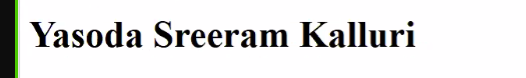